# Hopper NEAT — Hyperparameter Search Analysis

Sweep: `pop_size` × `generation_limit` × `seed` → 27 runs total.

**Part A** — Results CSV (final best fitness per run)  
**Part B** — MLflow per-generation metrics (training curves, species dynamics, etc.)

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

---
# Part A — Results CSV Analysis

In [69]:
df = pd.read_csv('../hyperparam_results/results.csv')
df.head()

,pop_size,generation_limit,seed,best_fitness,time_s
0,512,100,42,2363.767334,384.0
1,512,100,123,3299.302490,385.0
2,512,100,456,2490.369141,382.9
3,512,200,42,3262.174316,739.9
4,512,200,123,3346.377441,747.1


## A1 — Overall Summary

In [70]:
df[['best_fitness', 'time_s']].describe().round(2)

,best_fitness,time_s
count,27.00,27.00
mean,3305.12,885.35
std,336.29,385.02
min,2363.77,382.90
25%,3231.98,546.70
50%,3391.58,850.80
75%,3498.41,1107.90
max,3730.00,1587.70


## A2 — Descriptive Statistics by `pop_size`

In [71]:
df.groupby('pop_size')['best_fitness'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(2)

,count,mean,std,min,median,max
pop_size,,,,,,
512,9,3150.79,423.59,2363.77,3299.30,3507.27
1024,9,3289.13,305.14,2704.95,3391.58,3601.57
2048,9,3475.45,187.82,3204.68,3489.54,3730.00


## A3 — Descriptive Statistics by `generation_limit`

In [72]:
df.groupby('generation_limit')['best_fitness'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(2)

,count,mean,std,min,median,max
generation_limit,,,,,,
100,9,2990.75,389.07,2363.77,3204.68,3391.58
200,9,3416.40,141.55,3190.90,3430.42,3654.00
300,9,3508.22,156.86,3194.19,3507.27,3730.00


## A4 — Descriptive Statistics by `seed`

In [73]:
df.groupby('seed')['best_fitness'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(2)

,count,mean,std,min,median,max
seed,,,,,,
42,9,3278.19,372.29,2363.77,3391.58,3650.3
123,9,3356.69,235.42,2892.09,3346.38,3730.0
456,9,3280.49,411.13,2490.37,3485.06,3654.0


## A5 — Descriptive Statistics by (`pop_size`, `generation_limit`)

In [74]:
df.groupby(['pop_size', 'generation_limit'])['best_fitness'].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(2)

count     mean     std      min   median      max
pop_size generation_limit                                                   
512      100                   3  2717.81  507.55  2363.77  2490.37  3299.30
         200                   3  3364.54  112.55  3262.17  3346.38  3485.06
         300                   3  3370.01  160.06  3194.19  3408.58  3507.27
1024     100                   3  2996.21  354.96  2704.95  2892.09  3391.58
         200                   3  3339.84  131.86  3190.90  3386.93  3441.68
         300                   3  3531.35   92.12  3427.05  3565.44  3601.57
2048     100                   3  3258.23   53.03  3204.68  3259.29  3310.73
         200                   3  3544.83  111.88  3430.42  3550.09  3654.00
         300                   3  3623.28  122.48  3489.54  3650.30  3730.00

## A6 — Pivot Tables

In [75]:
print('Mean Fitness (pop_size × generation_limit):')
display(df.pivot_table(index='pop_size', columns='generation_limit',
                       values='best_fitness', aggfunc=['mean', 'std']).round(2))

print('\nMean Runtime (seconds):')
display(df.pivot_table(index='pop_size', columns='generation_limit',
                       values='time_s', aggfunc='mean').round(1))

Mean Fitness (pop_size × generation_limit):


mean                       std                
generation_limit      100      200      300     100     200     300
pop_size                                                           
512               2717.81  3364.54  3370.01  507.55  112.55  160.06
1024              2996.21  3339.84  3531.35  354.96  131.86   92.12
2048              3258.23  3544.83  3623.28   53.03  111.88  122.48


Mean Runtime (seconds):


generation_limit,100,200,300
pop_size,,,
512,384.0,742.5,1104.4
1024,440.1,852.1,1250.8
2048,548.6,1062.4,1583.3


## A7 — Best Configuration

In [76]:
best_row = df.loc[df['best_fitness'].idxmax()]
print('Best single run:')
print(f"  pop_size={int(best_row['pop_size'])}, gen={int(best_row['generation_limit'])}, "
      f"seed={int(best_row['seed'])}, fitness={best_row['best_fitness']:.2f}")

mean_by_config = df.groupby(['pop_size', 'generation_limit'])['best_fitness'].mean()
bc = mean_by_config.idxmax()
print(f'\nBest config by mean fitness: pop_size={bc[0]}, gen={bc[1]}, '
      f'mean={mean_by_config.max():.2f}')

Best single run:
  pop_size=2048, gen=300, seed=123, fitness=3730.00

Best config by mean fitness: pop_size=2048, gen=300, mean=3623.28


## A8 — Visualizations

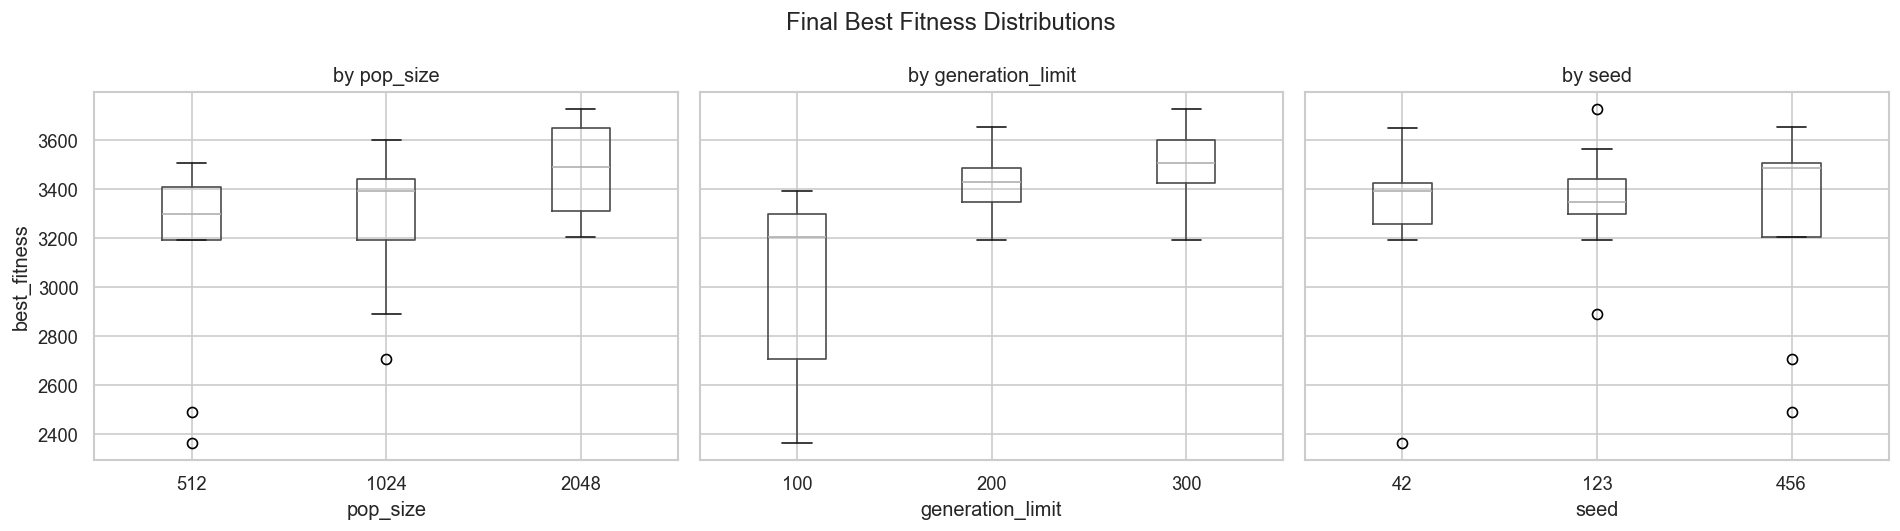

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, col in zip(axes, ['pop_size', 'generation_limit', 'seed']):
    df.boxplot(column='best_fitness', by=col, ax=ax)
    ax.set_title(f'by {col}')
    ax.set_xlabel(col)
axes[0].set_ylabel('best_fitness')
plt.suptitle('Final Best Fitness Distributions')
plt.tight_layout()
plt.show()

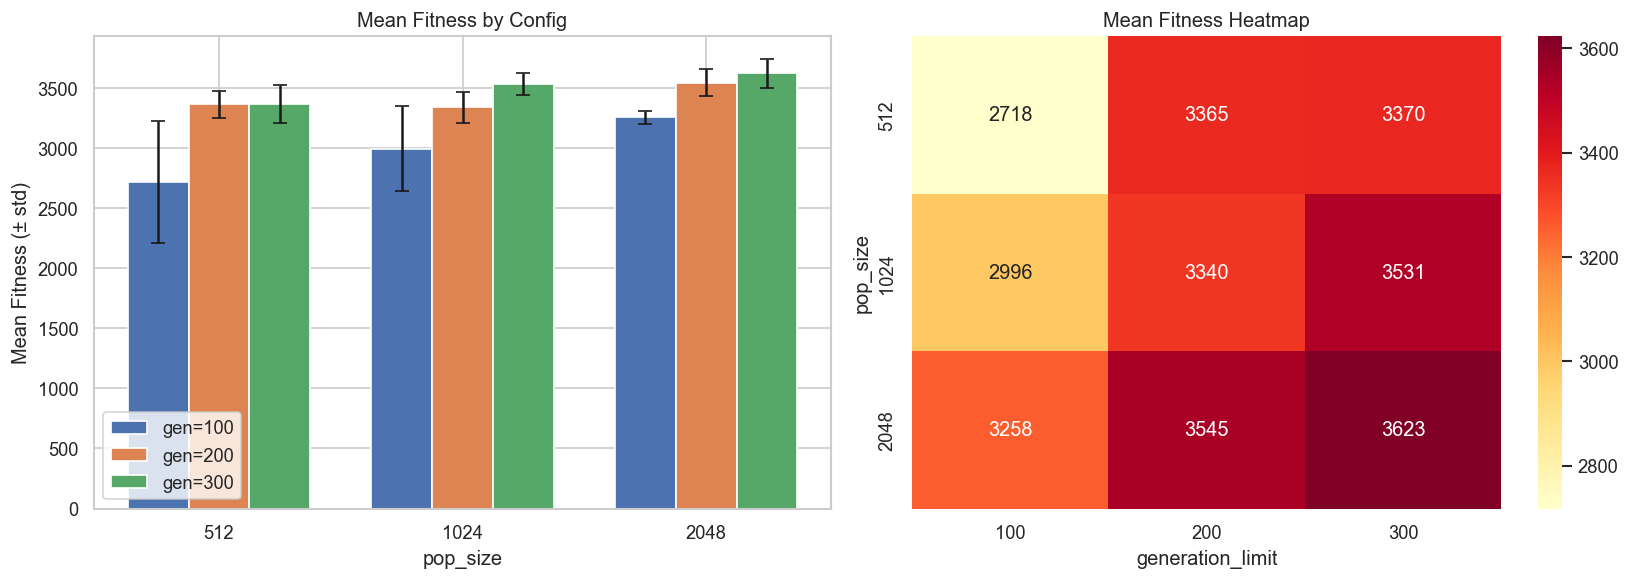

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
mean_p = df.pivot_table(index='pop_size', columns='generation_limit', values='best_fitness', aggfunc='mean')
std_p  = df.pivot_table(index='pop_size', columns='generation_limit', values='best_fitness', aggfunc='std')
x = np.arange(len(mean_p.index)); w = 0.25
for i, gen in enumerate(mean_p.columns):
    ax.bar(x + i*w, mean_p[gen], w, yerr=std_p[gen], capsize=4, label=f'gen={gen}')
ax.set_xticks(x + w); ax.set_xticklabels(mean_p.index)
ax.set_xlabel('pop_size'); ax.set_ylabel('Mean Fitness (± std)')
ax.set_title('Mean Fitness by Config'); ax.legend()

# Heatmap
ax = axes[1]
sns.heatmap(mean_p, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Mean Fitness Heatmap')
plt.tight_layout(); plt.show()

---
# Part B — MLflow Per-Generation Metrics

Extract training curves from the MLflow SQLite database.

In [79]:
import sqlite3

MLFLOW_DB = '../mlflow.db'
con = sqlite3.connect(MLFLOW_DB)

# Get runs from the hyperparam search only
runs = pd.read_sql_query("""
    SELECT run_uuid, name
    FROM runs
    WHERE name LIKE 'hopper_neat_pop%_seed%'
""", con)

# Get params for each run
params = pd.read_sql_query("""
    SELECT run_uuid, key, value FROM params
    WHERE run_uuid IN (SELECT run_uuid FROM runs WHERE name LIKE 'hopper_neat_pop%_seed%')
""", con)
params_wide = params.pivot(index='run_uuid', columns='key', values='value').reset_index()

# Get all per-generation metrics
metrics = pd.read_sql_query("""
    SELECT m.run_uuid, m.key, m.value, m.step
    FROM metrics m
    WHERE m.run_uuid IN (SELECT run_uuid FROM runs WHERE name LIKE 'hopper_neat_pop%_seed%')
    ORDER BY m.run_uuid, m.key, m.step
""", con)

con.close()

# Merge run info
metrics = metrics.merge(runs, on='run_uuid')
metrics = metrics.merge(params_wide[['run_uuid', 'pop_size', 'generation_limit', 'seed']], on='run_uuid')
for col in ['pop_size', 'generation_limit', 'seed']:
    metrics[col] = metrics[col].astype(int)

print(f'Loaded {len(metrics):,} metric rows across {runs.shape[0]} runs')
print(f'Metrics available: {sorted(metrics["key"].unique())}')

Loaded 62,520 metric rows across 30 runs
Metrics available: ['best_fitness', 'cost_time_ms', 'fitness/max', 'fitness/mean', 'fitness/min', 'fitness/std', 'fitness/valid_count', 'neat/avg_genome_n_conns', 'neat/best_genome_n_conns', 'neat/best_genome_n_nodes', 'neat/n_species', 'stability/stagnation_counter']


## B1 — Available Metrics Overview

In [80]:
metrics.groupby('key').agg(
    n_rows=('value', 'count'),
    mean=('value', 'mean'),
    std=('value', 'std'),
    min=('value', 'min'),
    max=('value', 'max'),
).round(2)

,n_rows,mean,std,min,max
key,,,,,
best_fitness,29,3283.65,333.88,2363.77,3730.00
cost_time_ms,5681,4189.25,692.33,859.21,6082.91
fitness/max,5681,2716.04,802.29,227.02,3730.00
fitness/mean,5681,849.02,209.00,15.11,1373.96
fitness/min,5681,1.60,5.28,-302.31,43.91
fitness/std,5681,780.83,280.66,27.86,1290.94
fitness/valid_count,5681,1160.60,640.05,504.00,2048.00
neat/avg_genome_n_conns,5681,29.16,3.52,20.66,41.59
neat/best_genome_n_conns,5681,29.32,5.03,11.00,50.00


## B2 — Fitness Training Curves (max fitness per generation)

Each line = one run, colored by `pop_size`, paneled by `generation_limit`.

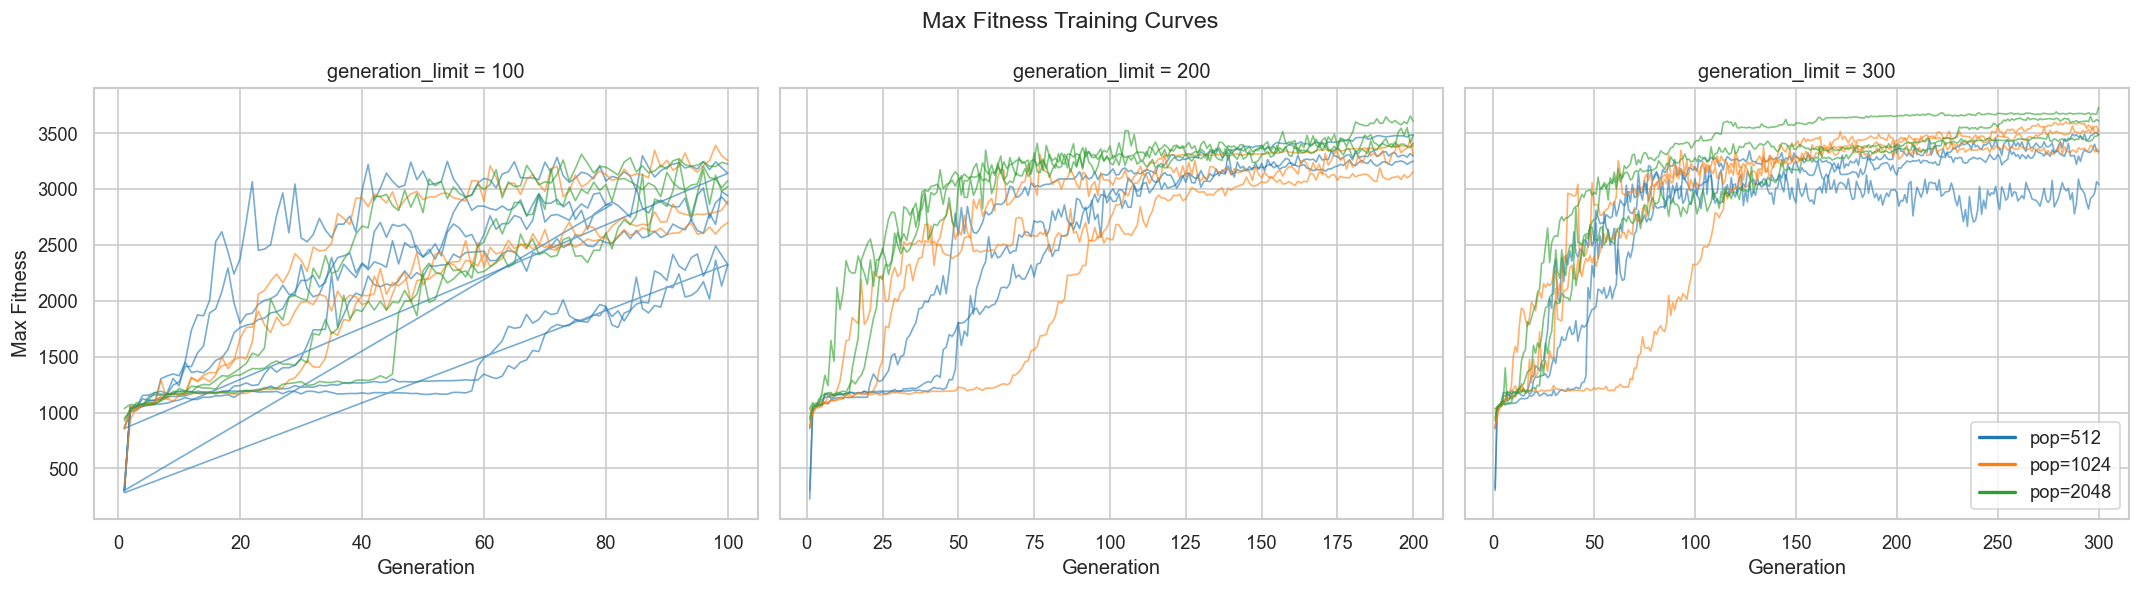

In [81]:
fit_max = metrics[metrics['key'] == 'fitness/max'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = {512: '#1f77b4', 1024: '#ff7f0e', 2048: '#2ca02c'}

for ax, gen in zip(axes, [100, 200, 300]):
    subset = fit_max[fit_max['generation_limit'] == gen]
    for _, grp in subset.groupby(['pop_size', 'seed']):
        ps = grp['pop_size'].iloc[0]
        ax.plot(grp['step'], grp['value'], alpha=0.6, color=colors[ps], linewidth=1)
    ax.set_title(f'generation_limit = {gen}')
    ax.set_xlabel('Generation')

axes[0].set_ylabel('Max Fitness')
from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], color=c, lw=2, label=f'pop={p}') for p, c in colors.items()]
axes[-1].legend(handles=legend_elems, loc='lower right')
plt.suptitle('Max Fitness Training Curves', fontsize=14)
plt.tight_layout(); plt.show()

## B3 — Mean Fitness Training Curves (with seed-averaged ribbon)

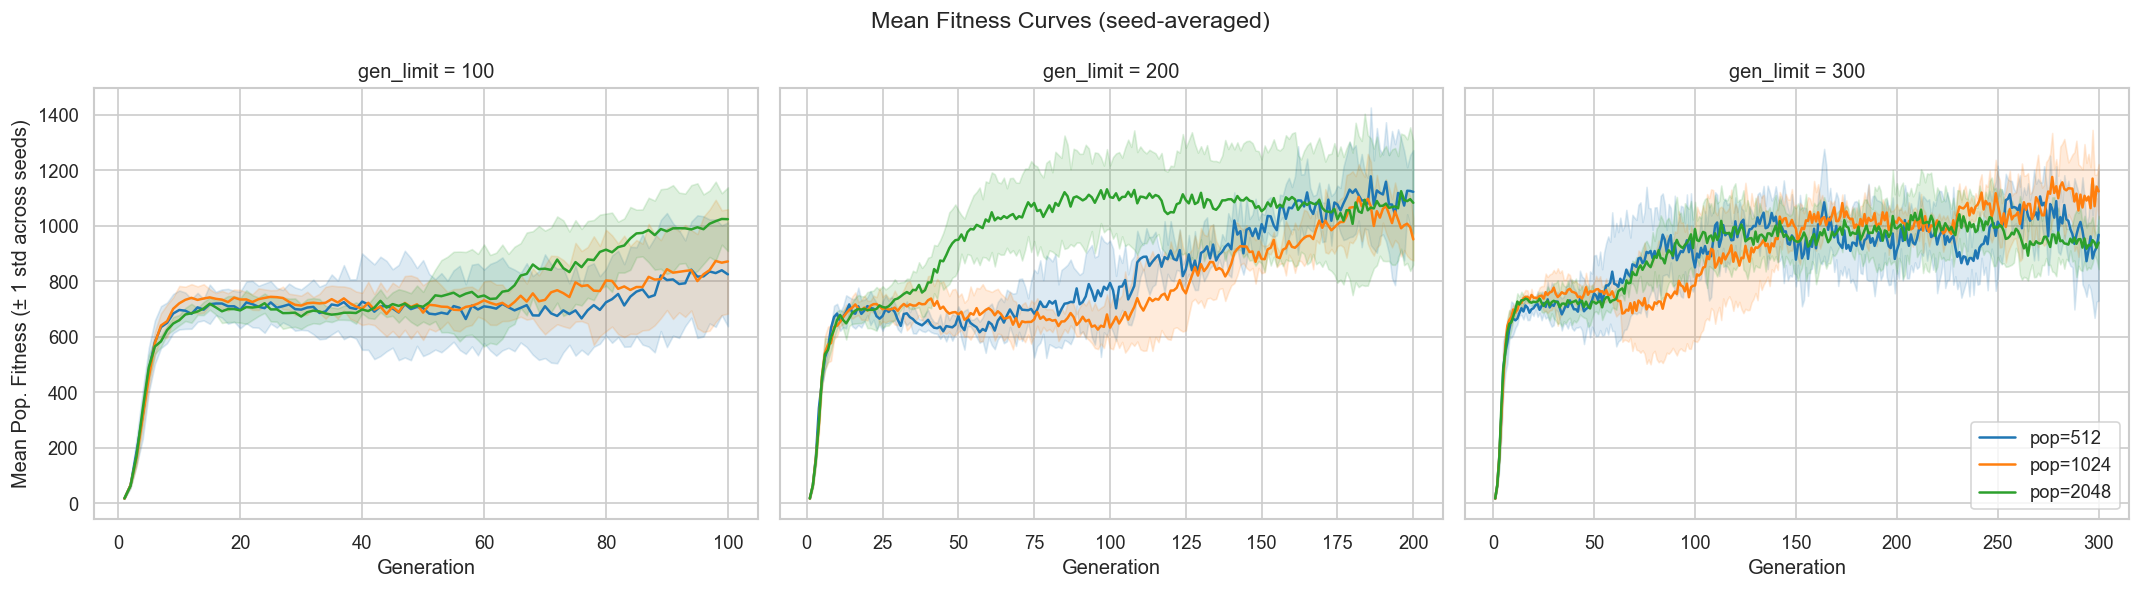

In [82]:
fit_mean = metrics[metrics['key'] == 'fitness/mean'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, gen in zip(axes, [100, 200, 300]):
    subset = fit_mean[fit_mean['generation_limit'] == gen]
    for ps, color in colors.items():
        grp = subset[subset['pop_size'] == ps]
        agg = grp.groupby('step')['value'].agg(['mean', 'std']).reset_index()
        ax.plot(agg['step'], agg['mean'], color=color, label=f'pop={ps}')
        ax.fill_between(agg['step'], agg['mean'] - agg['std'],
                        agg['mean'] + agg['std'], alpha=0.15, color=color)
    ax.set_title(f'gen_limit = {gen}')
    ax.set_xlabel('Generation')

axes[0].set_ylabel('Mean Pop. Fitness (± 1 std across seeds)')
axes[-1].legend(loc='lower right')
plt.suptitle('Mean Fitness Curves (seed-averaged)', fontsize=14)
plt.tight_layout(); plt.show()

## B4 — Species Count Over Generations

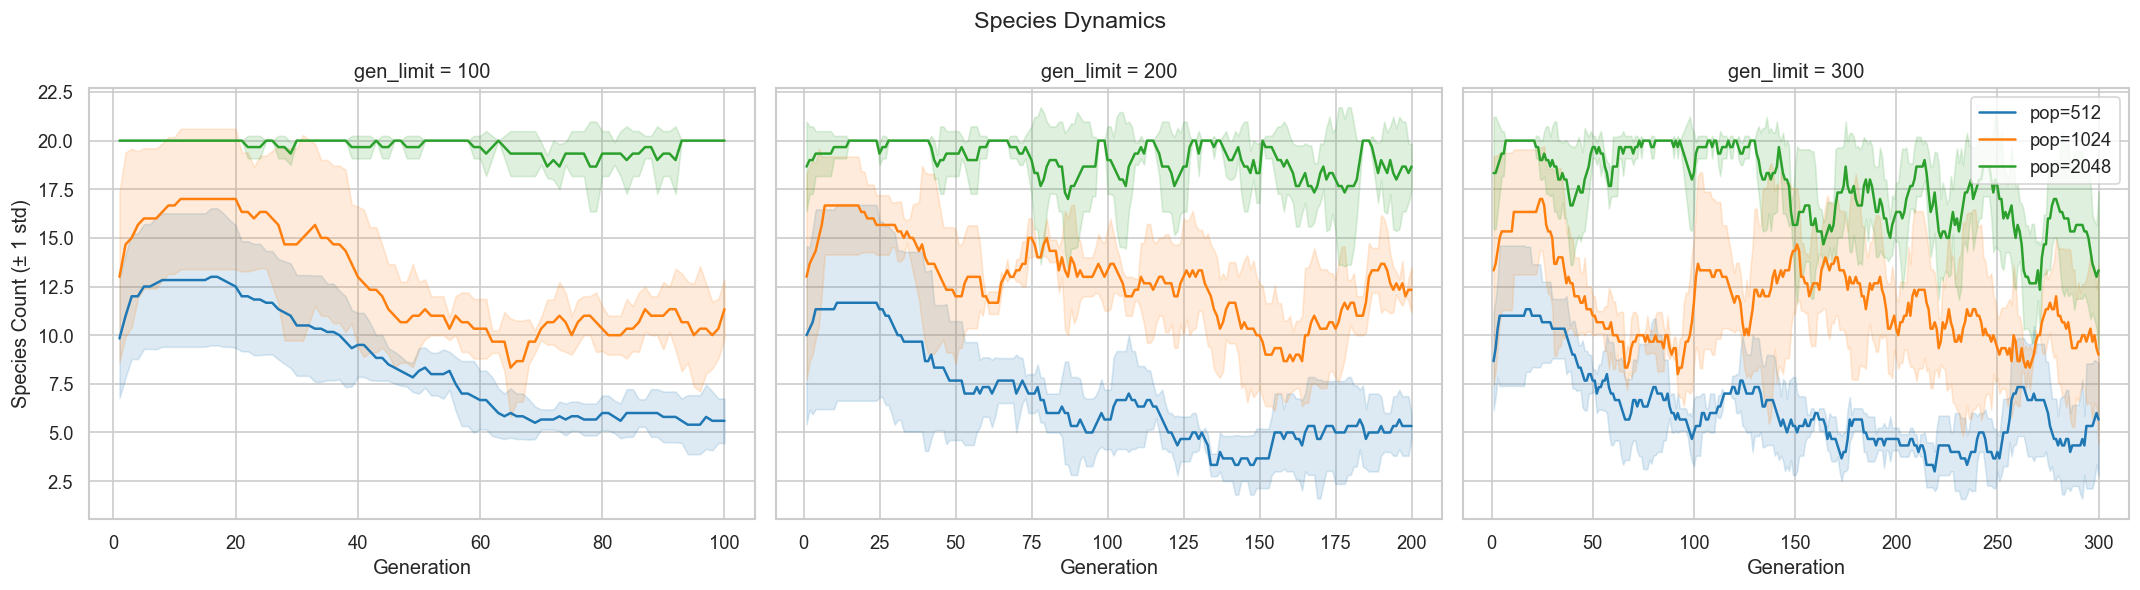

In [83]:
species = metrics[metrics['key'] == 'neat/n_species'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, gen in zip(axes, [100, 200, 300]):
    subset = species[species['generation_limit'] == gen]
    for ps, color in colors.items():
        grp = subset[subset['pop_size'] == ps]
        agg = grp.groupby('step')['value'].agg(['mean', 'std']).reset_index()
        ax.plot(agg['step'], agg['mean'], color=color, label=f'pop={ps}')
        ax.fill_between(agg['step'], agg['mean'] - agg['std'],
                        agg['mean'] + agg['std'], alpha=0.15, color=color)
    ax.set_title(f'gen_limit = {gen}')
    ax.set_xlabel('Generation')

axes[0].set_ylabel('Species Count (± 1 std)')
axes[-1].legend(loc='upper right')
plt.suptitle('Species Dynamics', fontsize=14)
plt.tight_layout(); plt.show()

## B5 — Genome Complexity (avg connections over generations)

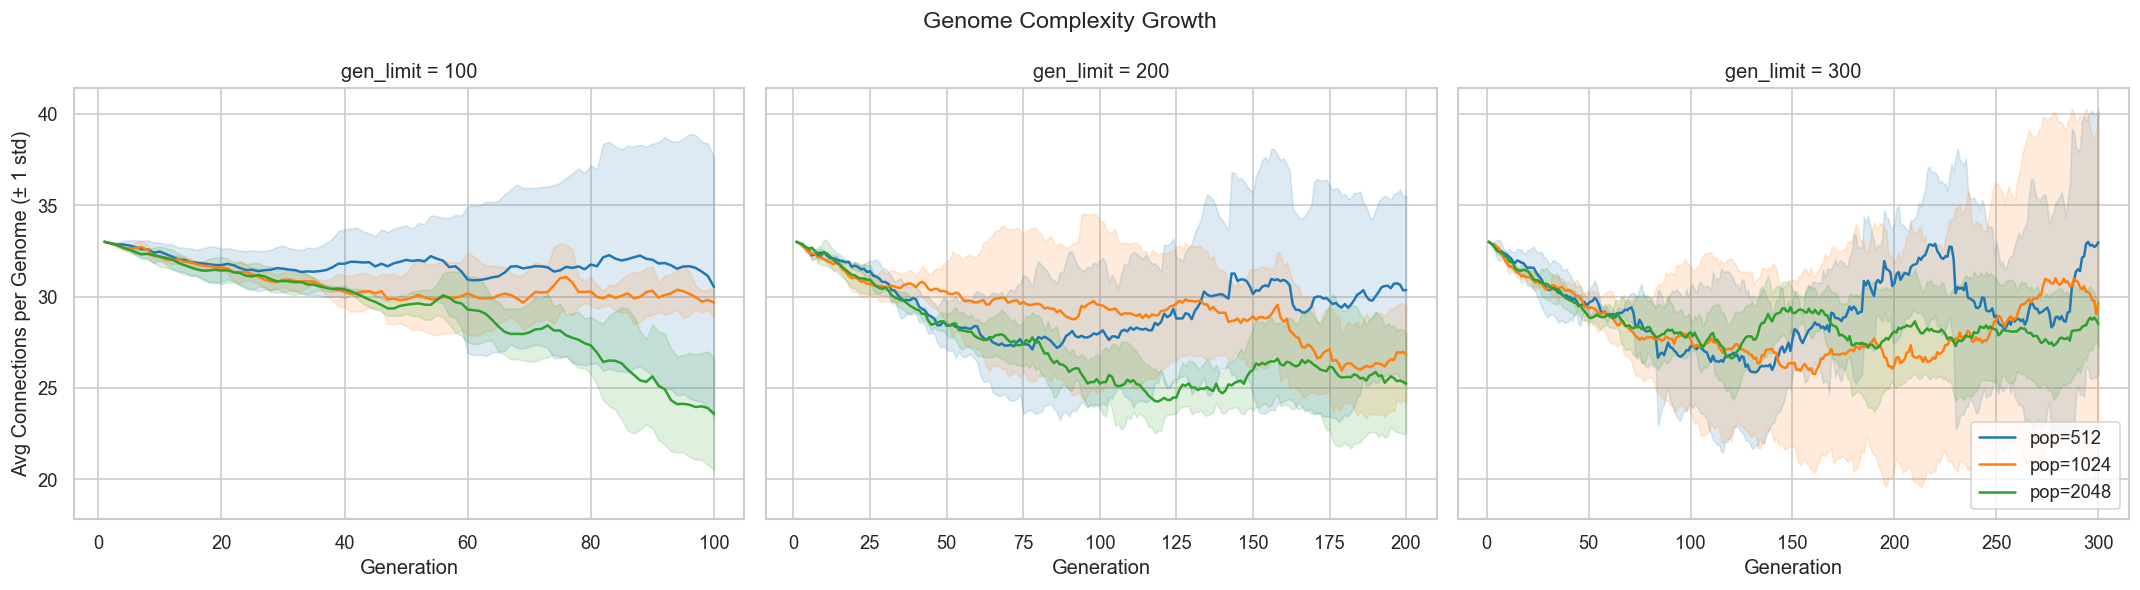

In [84]:
conns = metrics[metrics['key'] == 'neat/avg_genome_n_conns'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, gen in zip(axes, [100, 200, 300]):
    subset = conns[conns['generation_limit'] == gen]
    for ps, color in colors.items():
        grp = subset[subset['pop_size'] == ps]
        agg = grp.groupby('step')['value'].agg(['mean', 'std']).reset_index()
        ax.plot(agg['step'], agg['mean'], color=color, label=f'pop={ps}')
        ax.fill_between(agg['step'], agg['mean'] - agg['std'],
                        agg['mean'] + agg['std'], alpha=0.15, color=color)
    ax.set_title(f'gen_limit = {gen}')
    ax.set_xlabel('Generation')

axes[0].set_ylabel('Avg Connections per Genome (± 1 std)')
axes[-1].legend(loc='lower right')
plt.suptitle('Genome Complexity Growth', fontsize=14)
plt.tight_layout(); plt.show()

## B6 — Cost Time per Generation

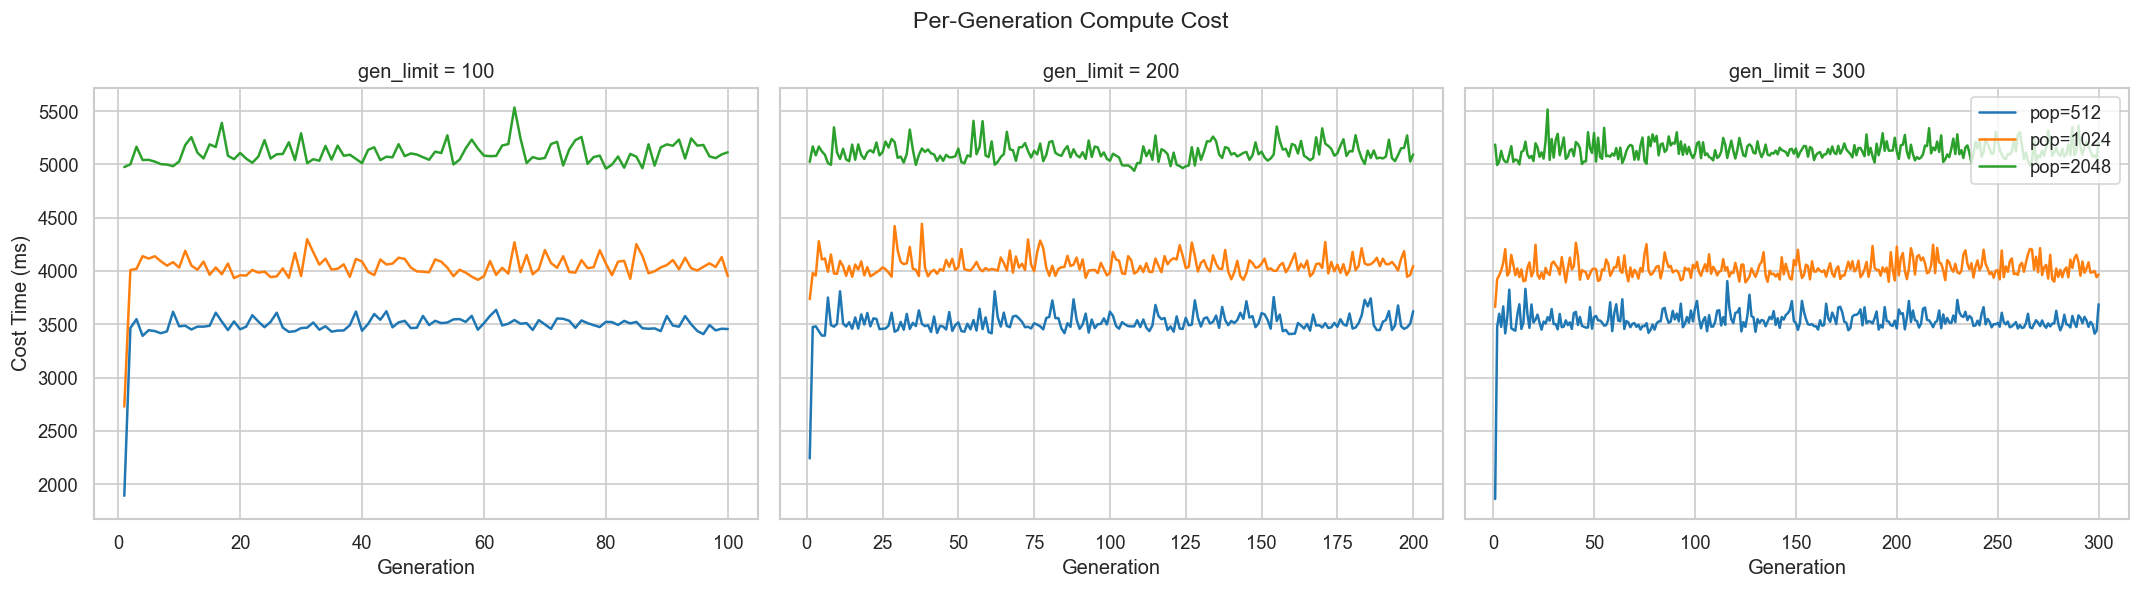

In [85]:
cost = metrics[metrics['key'] == 'cost_time_ms'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, gen in zip(axes, [100, 200, 300]):
    subset = cost[cost['generation_limit'] == gen]
    for ps, color in colors.items():
        grp = subset[subset['pop_size'] == ps]
        agg = grp.groupby('step')['value'].agg(['mean', 'std']).reset_index()
        ax.plot(agg['step'], agg['mean'], color=color, label=f'pop={ps}')
    ax.set_title(f'gen_limit = {gen}')
    ax.set_xlabel('Generation')

axes[0].set_ylabel('Cost Time (ms)')
axes[-1].legend(loc='upper right')
plt.suptitle('Per-Generation Compute Cost', fontsize=14)
plt.tight_layout(); plt.show()

## B7 — Fitness Variance Over Training

How the within-population fitness standard deviation evolves.

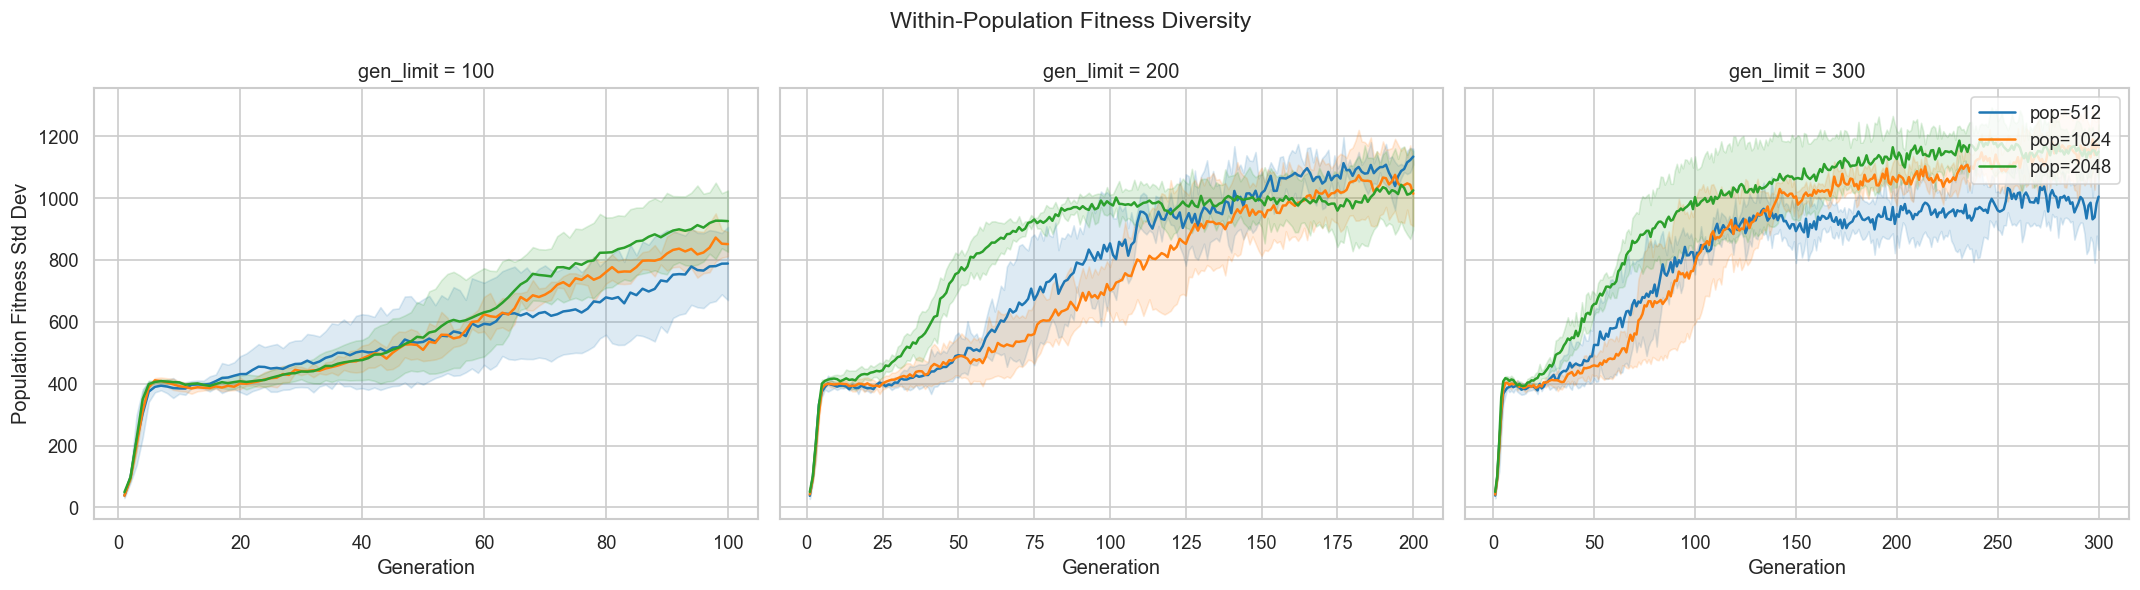

In [86]:
fit_std = metrics[metrics['key'] == 'fitness/std'].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, gen in zip(axes, [100, 200, 300]):
    subset = fit_std[fit_std['generation_limit'] == gen]
    for ps, color in colors.items():
        grp = subset[subset['pop_size'] == ps]
        agg = grp.groupby('step')['value'].agg(['mean', 'std']).reset_index()
        ax.plot(agg['step'], agg['mean'], color=color, label=f'pop={ps}')
        ax.fill_between(agg['step'], agg['mean'] - agg['std'],
                        agg['mean'] + agg['std'], alpha=0.15, color=color)
    ax.set_title(f'gen_limit = {gen}')
    ax.set_xlabel('Generation')

axes[0].set_ylabel('Population Fitness Std Dev')
axes[-1].legend(loc='upper right')
plt.suptitle('Within-Population Fitness Diversity', fontsize=14)
plt.tight_layout(); plt.show()

## B8 — Stagnation Counter

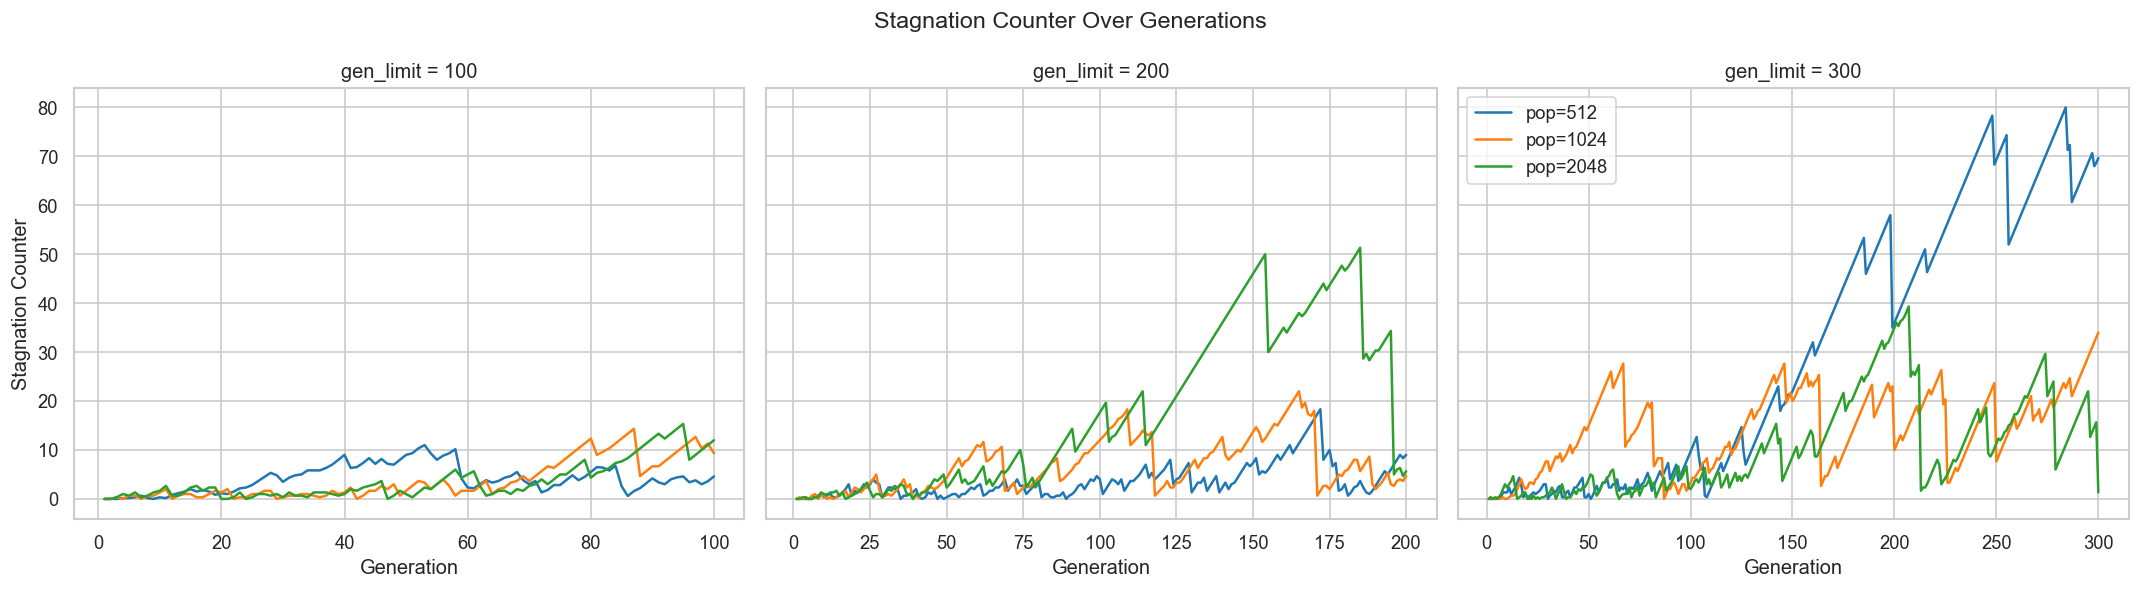

In [87]:
stag = metrics[metrics['key'] == 'stability/stagnation_counter'].copy()

if not stag.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, gen in zip(axes, [100, 200, 300]):
        subset = stag[stag['generation_limit'] == gen]
        for ps, color in colors.items():
            grp = subset[subset['pop_size'] == ps]
            agg = grp.groupby('step')['value'].agg(['mean', 'std']).reset_index()
            ax.plot(agg['step'], agg['mean'], color=color, label=f'pop={ps}')
        ax.set_title(f'gen_limit = {gen}')
        ax.set_xlabel('Generation')
    axes[0].set_ylabel('Stagnation Counter')
    axes[-1].legend()
    plt.suptitle('Stagnation Counter Over Generations', fontsize=14)
    plt.tight_layout(); plt.show()
else:
    print('No stagnation counter data found.')

## B9 — Summary Statistics: MLflow Metrics at Final Generation

In [88]:
# For each run, take the metric value at the last step
last_step = metrics.groupby(['run_uuid', 'key'])['step'].max().reset_index()
last_step.columns = ['run_uuid', 'key', 'last_step']

final_metrics = metrics.merge(last_step, on=['run_uuid', 'key'])
final_metrics = final_metrics[final_metrics['step'] == final_metrics['last_step']]

final_wide = final_metrics.pivot_table(
    index=['pop_size', 'generation_limit', 'seed'],
    columns='key', values='value'
).reset_index()

print('Final-generation metric summary by config:')
display(
    final_wide.groupby(['pop_size', 'generation_limit'])
    .mean(numeric_only=True)
    .round(2)
)

Final-generation metric summary by config:


key                         seed  best_fitness  cost_time_ms  fitness/max  \
pop_size generation_limit                                                   
512      100               207.0       2771.89       3488.15      2742.84   
         200               207.0       3364.54       3623.42      3342.94   
         300               207.0       3370.01       3688.16      3289.06   
1024     100               207.0       2996.21       3952.44      2949.17   
         200               207.0       3339.84       4048.03      3283.03   
         300               207.0       3531.35       3967.12      3455.10   
2048     100               207.0       3258.23       5114.25      3106.74   
         200               207.0       3544.83       5093.43      3499.11   
         300               207.0       3623.28       5205.51      3609.26   

key                        fitness/mean  fitness/min  fitness/std  \
pop_size generation_limit                                           
512      100                     802.62         2.87       777.29   
         200                    1122.05         5.50      1134.52   
         300                     967.28         0.80      1004.96   
1024     100                     871.12         1.61       851.44   
         200                     950.73         1.63      1014.60   
         300                    1123.50         2.37      1164.47   
2048     100                    1023.39        -0.37       925.91   
         200                    1082.46         1.24      1025.39   
         300                     939.15         1.87      1150.95   

key                        fitness/valid_count  neat/avg_genome_n_conns  \
pop_size generation_limit                                                 
512      100                            512.00                    30.50   
         200                            511.67                    30.35   
         300                            511.33                    32.97   
1024     100                           1024.00                    29.67   
         200                           1022.67                    26.83   
         300                           1018.00                    29.64   
2048     100                           2045.67                    23.59   
         200                           2047.67                    25.24   
         300                           2047.67                    28.51   

key                        neat/best_genome_n_conns  neat/best_genome_n_nodes  \
pop_size generation_limit                                                       
512      100                                  30.50                     18.33   
         200                                  31.00                     22.00   
         300                                  37.00                     27.00   
1024     100                                  31.00                     17.33   
         200                                  27.67                     20.67   
         300                                  29.67                     23.33   
2048     100                                  23.00                     16.67   
         200                                  24.33                     21.33   
         300                                  25.67                     22.00   

key                        neat/n_species  stability/stagnation_counter  
pop_size generation_limit                                                
512      100                         5.83                          5.83  
         200                         5.33                          9.00  
         300                         5.67                         69.67  
1024     100                        11.33                          9.33  
         200                        12.33                          4.67  
         300                         9.00                         34.00  
2048     100                        20.00                         12.00  
        